In [3]:
import csv
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Concatenate, Dot, Lambda

In [ ]:
""" from tqdm.notebook import tqdm
# Read data from text
with open('train_snli.txt') as file:
    data = file.readlines()

# prepare csv file
with open('data.csv', 'w', newline='') as csvfile:
    filenames = ['source_txt', 'plagiarism_txt', 'label']
    writer = csv.DictWriter(csvfile, fieldnames=filenames)

    writer.writeheader()
    for line in tqdm(data):
        parts = line.strip().split('\t')
        source_txt = parts[0]
        plagiarishm_txt = parts[1]
        label = int(parts[2])

        writer.writerow({
            'source_txt': source_txt,
            'plagiarism_txt': plagiarishm_txt,
            'label': label
        })
print('CSV file created successfully...') """

  0%|          | 0/367373 [00:00<?, ?it/s]

CSV file created successfully...


In [5]:
df = pd.read_csv('data.csv')

In [6]:
df.head()

,source_txt,plagiarism_txt,label
0,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",0
1,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",1
2,Children smiling and waving at camera,There are children present,1
3,Children smiling and waving at camera,The kids are frowning,0
4,A boy is jumping on skateboard in the middle o...,The boy skates down the sidewalk.,0


In [7]:
df.isnull().sum()

source_txt        0
plagiarism_txt    4
label             0
dtype: int64

In [8]:
df.duplicated().sum()

454

In [9]:
df.dropna(inplace=True)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.shape)

source_txt        0
plagiarism_txt    0
label             0
dtype: int64
0
(366915, 3)


<Axes: xlabel='label'>

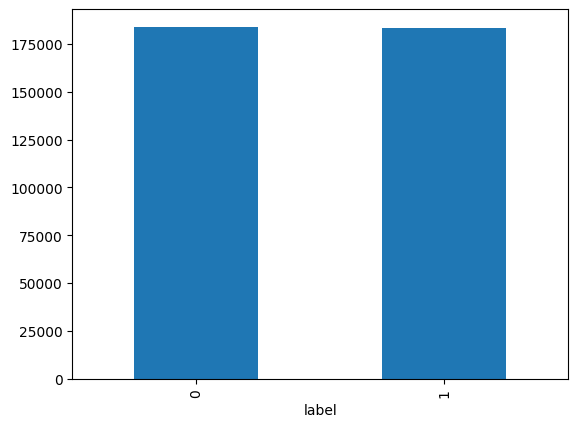

In [12]:
df['label'].value_counts().plot(kind='bar')

In [13]:
print(df['source_txt'][1])
print(df['plagiarism_txt'][1])

A person on a horse jumps over a broken down airplane.
A person is outdoors, on a horse.


In [14]:
import string


def preprocess_text(text):
    if isinstance(text, str):
        # Remove punctuation
        text = text.translate(str.maketrans("", "", string.punctuation))
        # Convert to lowercase
        text = text.lower()
    return text

In [15]:
df['source_txt'] = df['source_txt'].apply(preprocess_text)
df['plagiarism_txt'] = df['plagiarism_txt'].apply(preprocess_text)

In [16]:
df['source_txt'][1]

'a person on a horse jumps over a broken down airplane'

In [17]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['source_txt'] + '' + df['plagiarism_txt'])
X = tokenizer.texts_to_sequences(df['source_txt'] + '' + df['plagiarism_txt'])
X = pad_sequences(X)

In [18]:
y = df['label']

In [19]:
xtrain, xtest,ytrain,ytest = train_test_split(X,y,test_size=0.2)

In [20]:
""" vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100
sequence_length = X.shape[1]

model = Sequential([
    Input(shape=(sequence_length,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])
model.summary() """

" vocab_size = len(tokenizer.word_index) + 1\nembedding_dim = 100\nsequence_length = X.shape[1]\n\nmodel = Sequential([\n    Input(shape=(sequence_length,)),\n    Embedding(input_dim=vocab_size, output_dim=embedding_dim),\n    LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),\n    LSTM(64, dropout=0.2, recurrent_dropout=0.2),\n    Dense(1, activation='sigmoid')\n])\nmodel.summary() "

In [21]:
""" from keras.callbacks import EarlyStopping
callback = EarlyStopping(monitor='val_loss', patience=3,
                         restore_best_weights=True) """

" from keras.callbacks import EarlyStopping\ncallback = EarlyStopping(monitor='val_loss', patience=3,\n                         restore_best_weights=True) "

In [22]:
""" model.compile(loss='binary_crossentropy',
            optimizer='adam', metrics=['accuracy'])

# Step 6: Train the model
model.fit(xtrain, ytrain, batch_size=64, epochs=1,
        validation_data=[xtest, ytest], callbacks=callback) """

" model.compile(loss='binary_crossentropy',\n            optimizer='adam', metrics=['accuracy'])\n\n# Step 6: Train the model\nmodel.fit(xtrain, ytrain, batch_size=64, epochs=1,\n        validation_data=[xtest, ytest], callbacks=callback) "

In [23]:
""" import pickle
model.save('model_cpu.h5')
with open('tokenizer.pkl', 'wb') as file:
    pickle.dump(tokenizer, file) """

" import pickle\nmodel.save('model_cpu.h5')\nwith open('tokenizer.pkl', 'wb') as file:\n    pickle.dump(tokenizer, file) "

In [24]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load your model
model = load_model('model_cpu.h5')

# Quantize the model
quantized_model = tf.keras.models.clone_model(model)
quantized_model.set_weights(model.get_weights())
quantized_model.compile(optimizer=model.optimizer, loss=model.loss)

# Save the quantized model
quantized_model.save('quantized_model.h5')

In [25]:
def pre_text(text):
    sequences = tokenizer.texts_to_sequences([text])
    padded_sequences = pad_sequences(sequences, maxlen=111)
    return padded_sequences


def prdict_plagiarism(text):
    process_text = pre_text(text)
    predictions = model.predict(process_text)
    return predictions[0][0]


new_text = "a few people in a restaurant setting one of them is drinking orange juice"
predictions = prdict_plagiarism(new_text)
if predictions > .5:

    print('This Text Has Plagiarism With Similarity Score IS:  ', predictions)
else:
    print("This Text Has No Plagiarism")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
This Text Has No Plagiarism


In [26]:
df['plagiarism_txt'][50]

'two adults walk across a street'

In [27]:
print(df['source_txt'][10])
print(df['plagiarism_txt'][10])

a few people in a restaurant setting one of them is drinking orange juice
the diners are at a restaurant


In [ ]:
import ipywidgets as widgets
from IPython.display import display

text_input = widgets.Text(
    value='A person ordered omlette',
    description='New Text to Check',
    disabled=False
)
plag = widgets.Output()


def on_type(data):
    with plag:
        plag.clear_output()
        new_text = text_input.value
        score = prdict_plagiarism(new_text)
        if score > 0.5:
            message = f"⚠️ This Text Has Plagiarism. Similarity Score: {score:.2f}"
        else:
            message = "✅ This Text Has No Significant Plagiarism."
        print(message)

# Hook observer
text_input.observe(on_type, names='value')

# Display
display(text_input, plag)

Text(value='A person ordered omlette', description='New Text to Check')

Output()